
## (o_prod_rt) model for PDF shaping (n samples)

This uses the new object oriented class for PDF shaping.

* o_prod_rt ...... i_h2i_rate, i_h2_temp, i_ng_rate, i_ng_temp, i_pci_rate, i_wpi_rate, i_sgi_rate, i_sgi_COH2ratio, i_sgi_ReProRatio, i_o2_volfract, i_hbtemp, i_wind_rt, i_blast_H2O, i_bdn_H2O

## Web applicationi inputs and 1 outputs

Run interactively on the web at: https://rcalix1.github.io/ProbabilityDensityFunctionsFromNeuralNets/experiments/2023/july2023/XGBoost/deployment/tuyere/




## Inputs


(2, 'i_h2i_rate').........i_h2i_rate

(3, 'i_pci_rate').........i_pci_rate

(4, 'i_wpi_rate').........i_wpi_rate

(5, 'i_ngi_rate').........i_ng_rate

(6, 'i_o2_volfract').......i_o2_volfract

(7, 'i_ng_temp')...........i_ng_temp

(8, 'i_h2_temp')...........i_h2_temp

(9, 'i_hbtemp')............i_hbtemp

(10, 'i_wind_rt')..........i_wind_rt

(11, 'i_blastH2O').........i_blast_H2O

(12, 'i_BdnH2O')............i_bdn_H2O

(13, 'i_sgi_rate').........i_sgi_rate

(15, 'i_sgi_COH2ratio').....i_sgi_COH2ratio

(16, 'i_sgi_ReProRatio')....i_sgi_ReProRatio


  

## Outputs


(39, 'o_prod_rt')





## Installs


In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime



## Imports


In [2]:

import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)




In [3]:

import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt



/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk



## Instantiate PDF shaping and regression class


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()



## Initialize parameters


In [6]:

PDFshapingOBJ.N_error_range = 5         ## 20
PDFshapingOBJ.mean_impulse  = 0.0       ## -7.0      ## 0.0
PDFshapingOBJ.std_impulse   = 0.001     ## 1.0
PDFshapingOBJ.kde_std       = 0.5       ## 0.1       ## 0.5      ## 3.0  ## smaller is better approximation?
PDFshapingOBJ.bandwidth     = 0.2       ## 0.2->more jagged, 2.0->more smooth


In [7]:

PDFshapingOBJ.initializeImpulseGaussian()



## Run checks


In [8]:

## print(PDFshapingOBJ.x_range_impulse_func )
## print(PDFshapingOBJ.impulse_func_vector_vals )
## print(PDFshapingOBJ.quadratic_weights)
print(PDFshapingOBJ.x_range_impulse_func.shape )
print(PDFshapingOBJ.impulse_func_vector_vals.shape )
print(PDFshapingOBJ.quadratic_weights.shape)
 
print( sum(PDFshapingOBJ.impulse_func_vector_vals) )      ## should add up to 100 (i.e. 1.0 prob density)


torch.Size([1000])
torch.Size([1000])
torch.Size([1000])
tensor(100.0000)


In [9]:

## plt.plot(PDFshapingOBJ.x_range_impulse_func, PDFshapingOBJ.impulse_func_vector_vals)
## plt.show()



## RUN KDE test


In [10]:

## PDFshapingOBJ.test_torchKDE_with_fake_data()



## Load Data


In [11]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [12]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,0,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [13]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

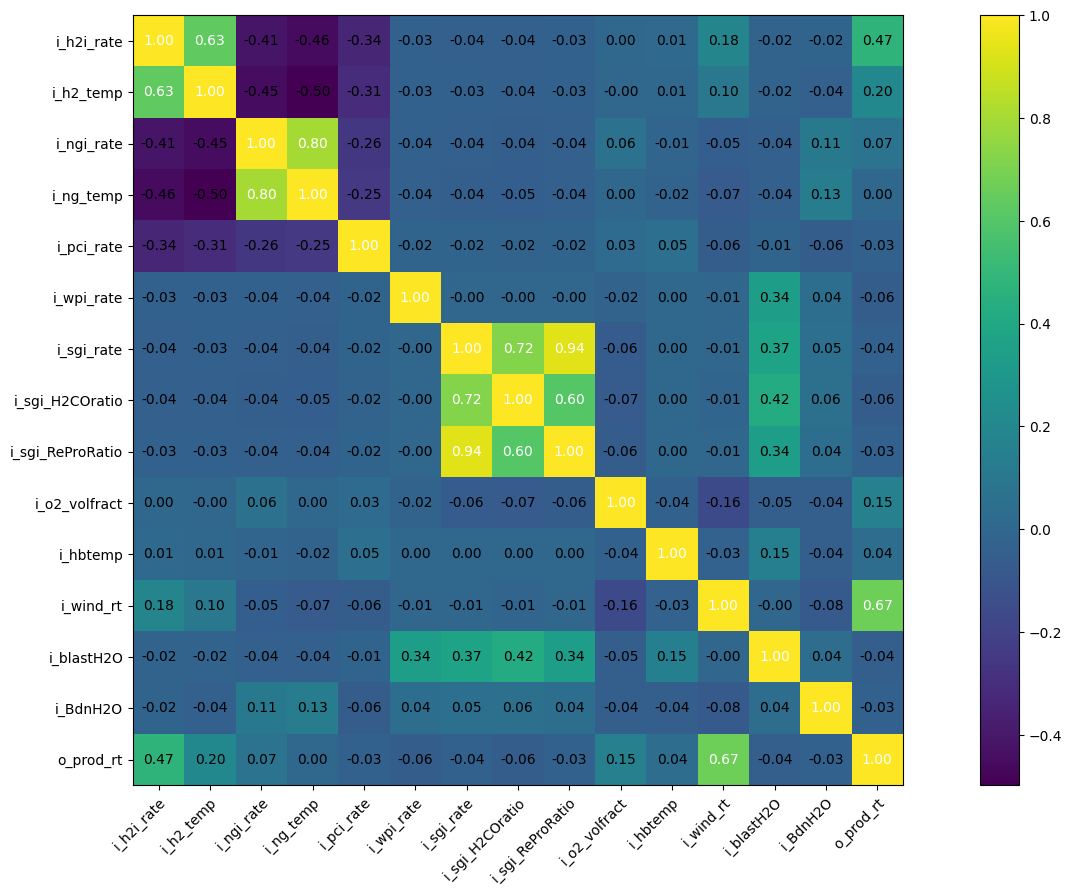

In [14]:

PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_sgi_rate','i_sgi_H2COratio','i_sgi_ReProRatio','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','i_blastH2O','i_BdnH2O','o_prod_rt']

ONNX_name = 'o_prod_rt'


PDFshapingOBJ.print_correlation_coefficients()


In [15]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)



## Select inputs and outputs


In [16]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [ 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16 ] , 
                   outputs= [ 39 ]   
)







14
1


In [17]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 14)
(4999, 1)


In [18]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [19]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 14)
(1000, 14)
(3999, 1)
(1000, 1)


In [20]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [21]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [22]:

PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## NN architectures


In [23]:

#######################################################
## Linear Regression

class LinRegNet_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 1) 
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)

    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        y_scaled = self.linear1(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled

    
#############################################################
## Multi-Layer Perceptron

class MLP_Net_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
    
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        
        y_scaled = self.linear2(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

#############################################################
## Deep Learning model with 2 hidden layers


class DL_Net_SIO(nn.Module):
    
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 6)
        self.act2    = nn.Sigmoid() 
        self.linear3 = nn.Linear(6, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
        
        ## nn.init.xavier_uniform_(self.linear3.weight)
        ## nn.init.zeros_(self.linear3.bias)
    
    ## perform inference
    def forward(self, x):
        
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.act2(x)
        x = self.dropout(x)
        
        y_scaled = self.linear3(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled


In [24]:

#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        ## F1
        self.f1_linear1 = nn.Linear(14, 1)       
        
        ## F2
        self.f2_linear1 = nn.Linear(14, 10)
        self.f2_act1    = nn.Sigmoid()                    ## Tanh()                       
        self.f2_linear2 = nn.Linear(10, 1)       
        self.f2_dropout = nn.Dropout(0.25)
        
        
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    



## Results for g(x) = F1(x) + F2(x) with No PDF shaping

F1 = Linear

F2 = Nonlinear


In [25]:

def fit_y_scaled(num_epochs, model, loss_fn, opt):
    
    PDFshapingOBJ.list_metric = []
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()
        
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
            
            
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(
            torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()   )
            )
        )
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,           PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy()  ))
    


In [26]:

PDFshapingOBJ.the_string           = "No_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = ONNX_name


0  loss=  tensor(0.8010, grad_fn=<MseLossBackward0>)
200  loss=  tensor(0.0723, grad_fn=<MseLossBackward0>)
400  loss=  tensor(0.0795, grad_fn=<MseLossBackward0>)
600  loss=  tensor(0.2365, grad_fn=<MseLossBackward0>)
800  loss=  tensor(0.0232, grad_fn=<MseLossBackward0>)
1000  loss=  tensor(0.0208, grad_fn=<MseLossBackward0>)
1200  loss=  tensor(0.3454, grad_fn=<MseLossBackward0>)
1400  loss=  tensor(0.1324, grad_fn=<MseLossBackward0>)
1600  loss=  tensor(0.0538, grad_fn=<MseLossBackward0>)
1800  loss=  tensor(0.0192, grad_fn=<MseLossBackward0>)


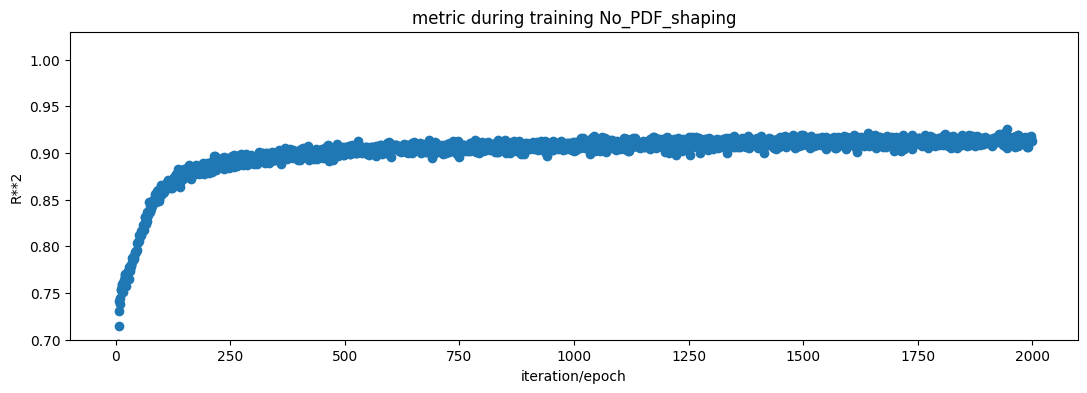

Training loss: tensor(0.0763, grad_fn=<MseLossBackward0>)
Training R**2: 0.9165114692009448
Test loss - scaled: tensor(0.0759, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(175545.3438, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: 0.9108679191141359
Testing R**2 - descaled: 0.9108679203589533
*****
*****
Testing R**2 - Output: 0 o_prod_rt 0.9108679203589533


In [27]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)

opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate   )
loss_fn = F.mse_loss


fit_y_scaled(PDFshapingOBJ.N_EPOCHS, model, loss_fn, opt)


pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,         PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,       PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))

PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [28]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(6174.569, 6550.0)
**************************************************
preds, real
(8220.775, 8390.0)
**************************************************
preds, real
(9515.174, 9520.0)
**************************************************
preds, real
(9656.39, 9610.0)
**************************************************
preds, real
(10623.281, 10500.0)
**************************************************
preds, real
(8691.306, 8630.0)
**************************************************
preds, real
(9034.887, 8800.0)
**************************************************
preds, real
(8163.7534, 7167.407)
**************************************************
preds, real
(6917.1406, 6880.0)
**************************************************
preds, real
(9459.297, 9820.0)
**************************************************
preds, real
(7384.601, 7420.0)
**************************************************
preds, real
(11648.58, 11500.0)
**********

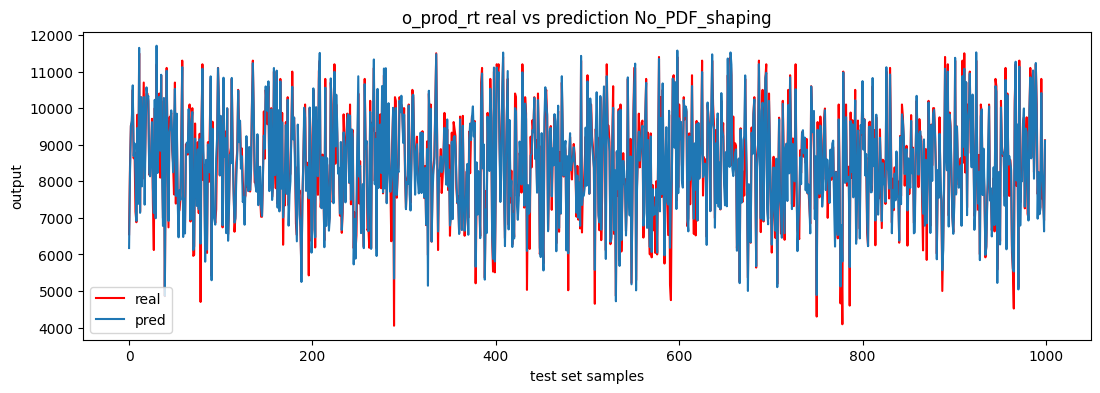

/Users/user/Desktop/CIVS_last_Phase/Forward/2025september/New5000SamplesDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


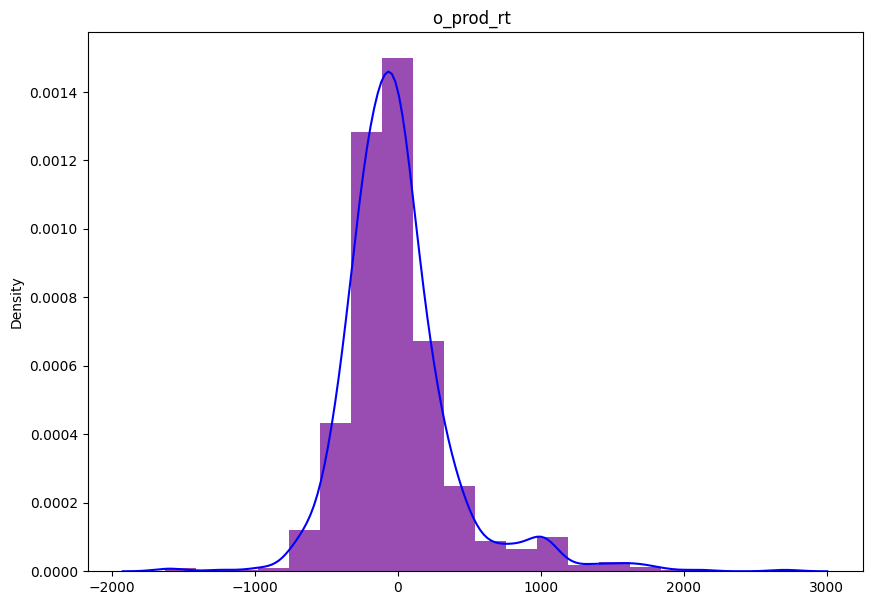

In [29]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )


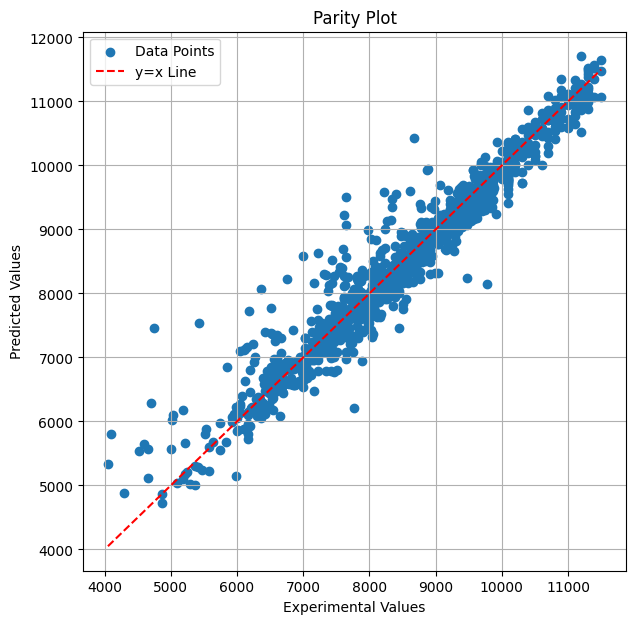

In [30]:

import matplotlib.pyplot as plt
import numpy as np

# Example data: Replace with your actual experimental and predicted values
## experimental_values = np.array([10, 20, 30, 40, 50])
## predicted_values    = np.array([11, 19, 32, 38, 51])

experimental_values = list_reals
predicted_values    = list_preds



plt.figure(figsize=(7, 7)) # Adjust figure size as needed
plt.scatter(experimental_values, predicted_values, label='Data Points')
plt.plot([min(experimental_values), max(experimental_values)],
        [min(experimental_values), max(experimental_values)],
        '--r', label='y=x Line') # Red dashed line for y=x

plt.xlabel('Experimental Values')
plt.ylabel('Predicted Values')
plt.title('Parity Plot')
plt.legend()
plt.grid(True)
plt.show()




## Export ONNX model


In [31]:


name_to_use_onnx = "ONNXmodels/F1plusF2NNs_" + ONNX_name + ".onnx"

model.eval()

dummy_input = torch.randn(1, 14)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  name_to_use_onnx, 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)




## To compare NNs to XGBoost


In [32]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [33]:

pred_descaled


tensor([[ 6321.1904],
        [ 8353.2881],
        [ 9472.1260],
        [ 9845.9434],
        [10499.2529],
        [ 8560.8809],
        [ 9035.0879],
        [ 7105.0503],
        [ 6789.1006],
        [ 9402.9531],
        [ 7333.4438],
        [11530.5293],
        [ 7134.3770],
        [10179.2998],
        [ 8080.2827],
        [ 9215.7246],
        [10495.2539],
        [ 7640.5283],
        [ 9311.3047],
        [10455.7500],
        [10299.1201],
        [10248.9873],
        [ 8139.1875],
        [ 8256.0312],
        [ 8605.7363],
        [ 9542.9883],
        [ 7288.0195],
        [ 7072.6421],
        [10107.7910],
        [ 7352.0732],
        [11524.4746],
        [ 8176.6040],
        [ 8933.2227],
        [10228.9482],
        [ 8868.3408],
        [10772.5938],
        [ 8465.9307],
        [ 6983.7505],
        [10156.6055],
        [ 5059.3867],
        [ 8896.8584],
        [10899.6895],
        [ 8823.6475],
        [ 6905.3564],
        [ 9641.6328],
        [ 

In [34]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: 0.9368072357906633
Testing R**2 - descaled: 0.9368072370912613



## Results for g(x) = F1(x) + F2(x) with PDF shaping

F1 = Linear

F2 = Nonlinear


In [35]:

def fit_y_scaled_PDF(num_epochs, num_epochs_pdf, model, loss_fn, opt, kl_loss, scheduler):
    
    PDFshapingOBJ.list_metric = []
      
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(r2_avg.detach().numpy())
        
        
    opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol  )    
        
    for epoch in range(num_epochs_pdf):
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
       
        error =   pred_scaled.float() - PDFshapingOBJ.y_train_tr_scaled.float()          ## 715  x 1
        
        basisFunc = PDFshapingOBJ.train_multiple_kernels_per_output( error )             ## 1000 x 1
        
        p_pred = basisFunc.float() 
        q_real = PDFshapingOBJ.impulse_func_vector_vals.unsqueeze(1).float() 
        
        
        diff = ( p_pred - q_real )**2              ## 1000 x 1
        diff = diff * PDFshapingOBJ.quadratic_weights.unsqueeze(1)      
          
        
        loss = torch.mean( diff  ) 
        

        ## loss_diff = loss_fn(p_pred, q_real)
        ## input_kl  = F.log_softmax(p_pred, dim=0) # F.log_softmax(p_kl)
        ## target_kl = F.softmax(    q_real, dim=0) # F.softmax(q_kl)
        ## loss =  loss_diff   ## kl_loss(input_kl, target_kl)  ##   +  torch.std(p_pred)
        
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        
      
        
        ## PDFshapingOBJ.updateImpulseGaussian_with_new_standard_deviation(decay_impulse_std )
        

        ## print(epoch, " loss= ", loss)
        if epoch % 5000 == 0:
            print(epoch, " loss= ", loss)
            print(PDFshapingOBJ.impulse_func_vector_vals.shape )
            print(PDFshapingOBJ.quadratic_weights.shape)
            print(error.shape)
            print(basisFunc.shape)
            ##### PDFshapingOBJ.print_errors_kdes(  error, basisFunc )
            print(PDFshapingOBJ.impulse_func_vector_vals.shape)
            print('Epoch-{0} lr: {1}'.format(epoch, opt.param_groups[0]['lr']))
      

        r2_avg = torch.mean(torch.tensor(
                 r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
        
        
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,       PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy() ))
    


In [36]:

PDFshapingOBJ.the_string           = "With_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = ONNX_name

PDFshapingOBJ.learning_rate_pdfcontrol  = 0.001       ## 0.001
PDFshapingOBJ.N_EPOCHS_PDF              = 30000
PDFshapingOBJ.N_EPOCHS                  = 0

decay_impulse_std                       = PDFshapingOBJ.std_impulse / PDFshapingOBJ.N_EPOCHS_PDF 


10000
0  loss=  tensor(0.0197, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3999, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-0 lr: 0.001
5000  loss=  tensor(0.0028, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3999, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-5000 lr: 0.001
10000  loss=  tensor(0.0019, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3999, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-10000 lr: 0.001
15000  loss=  tensor(0.0017, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3999, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-15000 lr: 0.001
20000  loss=  tensor(0.0017, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3999, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-20000 lr: 0.001
25000  loss=  tensor(0.0017, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3999, 1])
torch

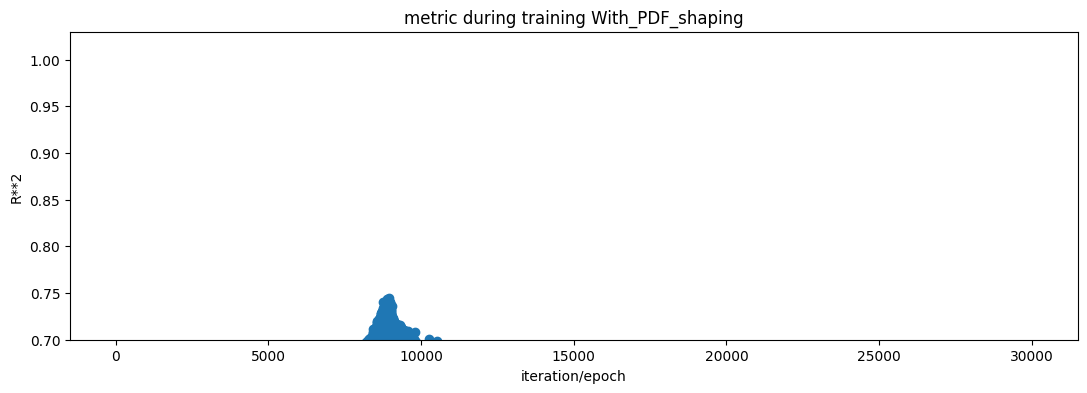

Training loss: tensor(1.7005, grad_fn=<MseLossBackward0>)
Training R**2: 0.36697931426609487
Test loss - scaled: tensor(2.3235, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(5376706.5000, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: 0.31981275545022325
Testing R**2 - descaled: 0.3198127942408344
*****
*****
Testing R**2 - Output: 0 o_prod_rt 0.3198127942408344


In [37]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)



opt         = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol    )


step_size_scheduler = int(PDFshapingOBJ.N_EPOCHS_PDF / 3)
print(step_size_scheduler)
                          
scheduler   = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.1)



loss_fn      = F.mse_loss
kl_loss      = nn.KLDivLoss(reduction="batchmean")
loss_softmax = F.binary_cross_entropy


fit_y_scaled_PDF(PDFshapingOBJ.N_EPOCHS, PDFshapingOBJ.N_EPOCHS_PDF, model, loss_fn, opt, kl_loss, scheduler)

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,       PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,     PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:',   r2_score( pred_scaled.detach().numpy(),PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()   ))


PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [38]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(6426.035, 6550.0)
**************************************************
preds, real
(8453.309, 8390.0)
**************************************************
preds, real
(9557.395, 9520.0)
**************************************************
preds, real
(9711.539, 9610.0)
**************************************************
preds, real
(10468.102, 10500.0)
**************************************************
preds, real
(8698.254, 8630.0)
**************************************************
preds, real
(8876.838, 8800.0)
**************************************************
preds, real
(-27702.16, 7167.407)
**************************************************
preds, real
(6822.8584, 6880.0)
**************************************************
preds, real
(9711.208, 9820.0)
**************************************************
preds, real
(7740.5557, 7420.0)
**************************************************
preds, real
(11372.164, 11500.0)
*******

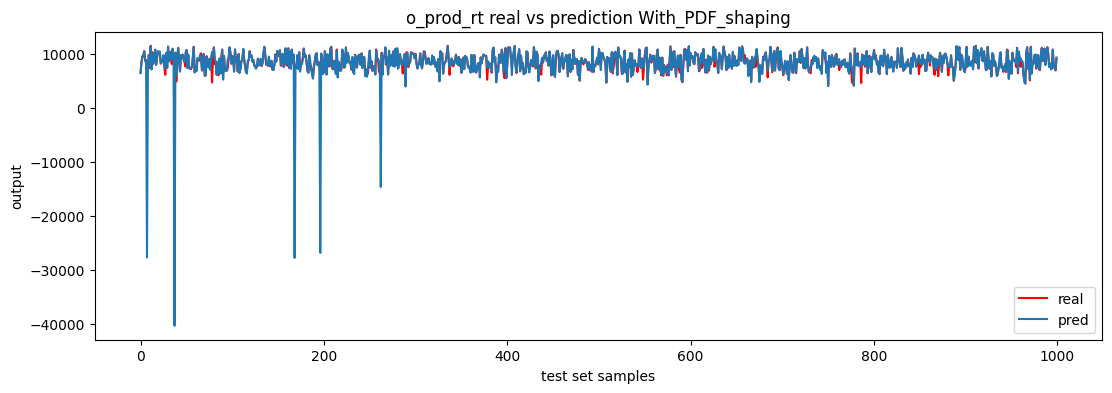

/Users/user/Desktop/CIVS_last_Phase/Forward/2025september/New5000SamplesDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


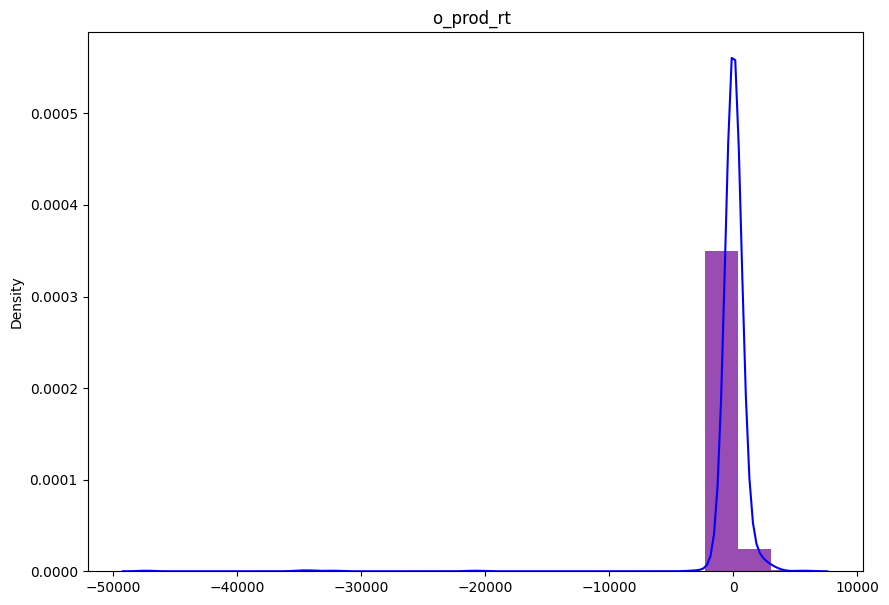

In [39]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )


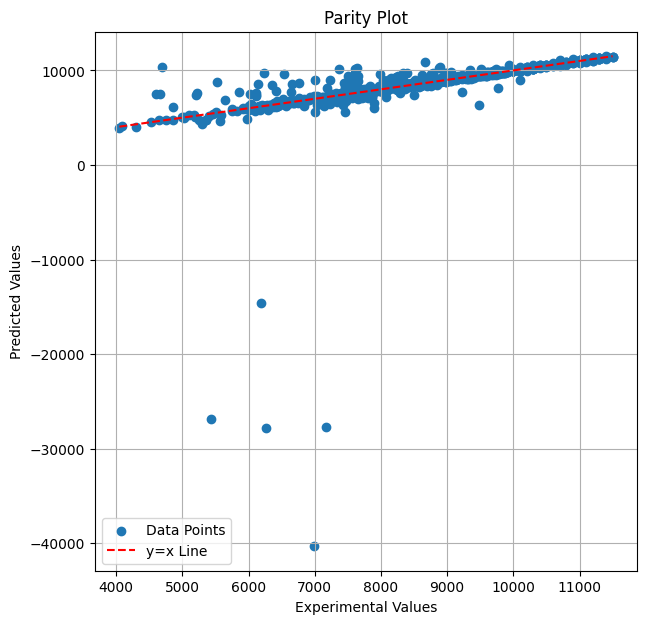

In [40]:

import matplotlib.pyplot as plt
import numpy as np

# Example data: Replace with your actual experimental and predicted values
## experimental_values = np.array([10, 20, 30, 40, 50])
## predicted_values    = np.array([11, 19, 32, 38, 51])

experimental_values = list_reals
predicted_values    = list_preds



plt.figure(figsize=(7, 7)) # Adjust figure size as needed
plt.scatter(experimental_values, predicted_values, label='Data Points')
plt.plot([min(experimental_values), max(experimental_values)],
        [min(experimental_values), max(experimental_values)],
        '--r', label='y=x Line') # Red dashed line for y=x

plt.xlabel('Experimental Values')
plt.ylabel('Predicted Values')
plt.title('Parity Plot')
plt.legend()
plt.grid(True)
plt.show()




## To compare to NNs to XGBoost


In [41]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [42]:

## y_pred

pred_descaled


tensor([[  6431.9214],
        [  8458.6504],
        [  9554.3086],
        [  9748.4834],
        [ 10338.4746],
        [  8641.3203],
        [  8909.9268],
        [-26654.7930],
        [  6859.9800],
        [  9719.9014],
        [  7739.2363],
        [ 11415.7617],
        [  7114.7808],
        [ 10129.1230],
        [  7878.1621],
        [  9380.2637],
        [ 10833.4912],
        [  7964.1006],
        [  9362.2705],
        [ 10505.3730],
        [ 10347.8955],
        [ 10328.4639],
        [  8305.4814],
        [  8489.9756],
        [  8633.0586],
        [  9674.9453],
        [  7410.7656],
        [  7305.7798],
        [ 10186.4365],
        [  6873.8745],
        [ 11409.7617],
        [  8575.6367],
        [  8979.5693],
        [ 10385.4600],
        [  9017.3867],
        [ 10878.5068],
        [  8717.1299],
        [-39320.1172],
        [ 10208.5508],
        [  6139.4941],
        [  9023.9199],
        [ 11041.7676],
        [  8892.8848],
        [  

In [43]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: 0.30745932205093873
Testing R**2 - descaled: 0.30745934246332374



## Export ONNX model


In [44]:

'''

model.eval()

dummy_input = torch.randn(1, 6)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)

'''


'\n\nmodel.eval()\n\ndummy_input = torch.randn(1, 6)\n\n\ninput_names = ["input1"]\noutput_names = ["output1", "output2"]\n\ntorch.onnx.export(\n  model, \n  dummy_input, \n  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", \n  verbose=False, \n  input_names  = input_names,\n  output_names = output_names\n)\n\n'


## XGBoost


In [45]:

regressor = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [46]:

regressor.fit(PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [47]:

print( len(PDFshapingOBJ.X_train  ))
print( len(PDFshapingOBJ.y_train  ))
  


3999
3999


In [48]:

## columns_thing = ['i_h2_inj_kg_thm', 'i_pul_coal_inj_kg_thm', 'i_nat_gas_inj_kg_thm', 'i_nat_gas_t_k', 
##                  'i_o2_vol_perce', 'i_hot_blast_temp_k', ]



## pd.DataFrame(regressor.feature_importances_.reshape(1, -1), columns=columns_thing)


In [49]:

y_pred = regressor.predict(PDFshapingOBJ.X_test )


In [50]:

y_pred


array([ 6473.2144,  8260.951 ,  9561.978 ,  9740.799 , 10366.536 ,
        8671.153 ,  8993.305 ,  6936.52  ,  7074.913 ,  9696.625 ,
        7225.1616, 11279.947 ,  7204.194 , 10174.921 ,  8018.096 ,
        9379.704 , 10759.435 ,  7443.952 ,  9375.915 , 10488.745 ,
       10121.02  , 10449.659 ,  8138.244 ,  8420.751 ,  8764.218 ,
        9131.624 ,  7551.5405,  6822.494 , 10136.404 ,  7814.2817,
       11550.138 ,  8300.061 ,  9287.199 , 10413.784 ,  8103.668 ,
       10928.939 ,  8555.797 ,  7033.329 , 10150.807 ,  5034.522 ,
        9034.215 , 10993.59  ,  8949.656 ,  6617.193 ,  9695.856 ,
        9692.048 ,  9836.499 ,  8992.973 ,  8586.51  ,  9079.614 ,
       10656.384 ,  7524.7812,  9775.96  ,  7509.792 ,  7414.0273,
        7640.564 ,  7650.0767,  9369.091 , 11273.599 ,  6635.2065,
        7540.394 ,  7053.097 ,  9032.403 ,  8885.649 ,  9082.896 ,
        9623.636 , 10196.781 ,  6985.676 ,  9279.39  , 10023.735 ,
        6250.355 ,  6844.276 ,  9522.936 ,  8294.29  ,  7579.6

In [51]:

mean_squared_error(PDFshapingOBJ.y_test , y_pred)


90729.13

In [52]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.9587434292554047

In [53]:

len(y_pred) 


1000

In [54]:

list_preds = []
list_reals = []

print( "preds, real"   )
  
for j in range(   len(y_pred)    ):
    print(   y_pred[j], PDFshapingOBJ.y_test[j][0]   )
    
    list_preds.append(   y_pred[j]   )
    list_reals.append(  PDFshapingOBJ.y_test[j][0]   )


preds, real
6473.2144 6550.0
8260.951 8390.0
9561.978 9520.0
9740.799 9610.0
10366.536 10500.0
8671.153 8630.0
8993.305 8800.0
6936.52 7167.407
7074.913 6880.0
9696.625 9820.0
7225.1616 7420.0
11279.947 11500.0
7204.194 7170.0
10174.921 10300.0
8018.096 8140.0
9379.704 9370.0
10759.435 10700.0
7443.952 8060.0
9375.915 9360.0
10488.745 10400.0
10121.02 10400.0
10449.659 10200.0
8138.244 8180.0
8420.751 8450.0
8764.218 8630.0
9131.624 9710.0
7551.5405 7410.0
6822.494 6120.0
10136.404 10000.0
7814.2817 7420.0
11550.138 11200.0
8300.061 8760.0
9287.199 9030.0
10413.784 10400.0
8103.668 8100.0
10928.939 10900.0
8555.797 8720.0
7033.329 6988.61
10150.807 10200.0
5034.522 4860.0
9034.215 9010.0
10993.59 11100.0
8949.656 8910.0
6617.193 6740.0
9695.856 9750.0
9692.048 9730.0
9836.499 9870.0
8992.973 8880.0
8586.51 8490.0
9079.614 7640.0
10656.384 10700.0
7524.7812 7390.0
9775.96 9660.0
7509.792 7510.0
7414.0273 7170.0
7640.564 7210.0
7650.0767 7520.0
9369.091 9280.0
11273.599 11300.0
6635.2065

In [55]:

len( list_preds )


1000

In [56]:

len( list_reals )


1000

In [57]:

PDFshapingOBJ.the_string           = "XGBoost"
PDFshapingOBJ.furnace_model_name   = ONNX_name


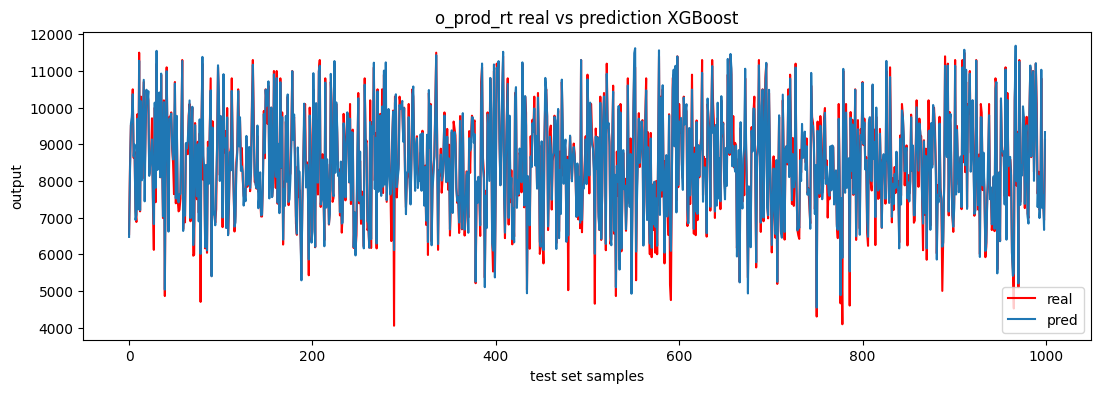

/Users/user/Desktop/CIVS_last_Phase/Forward/2025september/New5000SamplesDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


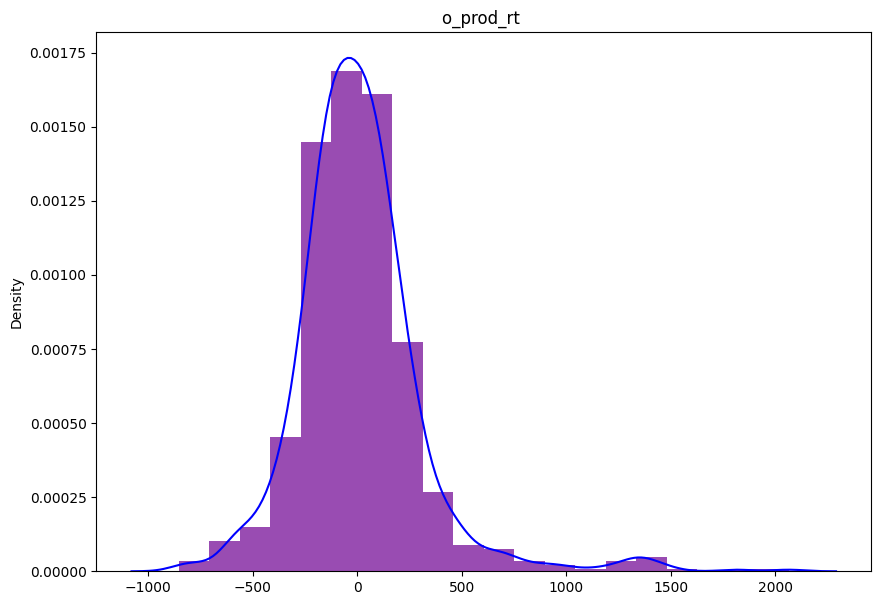

In [58]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )


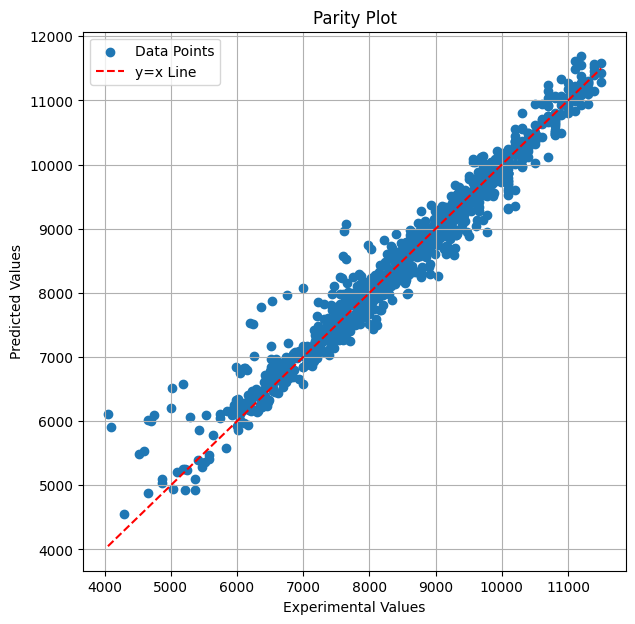

In [59]:

import matplotlib.pyplot as plt
import numpy as np

# Example data: Replace with your actual experimental and predicted values
## experimental_values = np.array([10, 20, 30, 40, 50])
## predicted_values    = np.array([11, 19, 32, 38, 51])

experimental_values = list_reals
predicted_values    = list_preds



plt.figure(figsize=(7, 7)) # Adjust figure size as needed
plt.scatter(experimental_values, predicted_values, label='Data Points')
plt.plot([min(experimental_values), max(experimental_values)],
        [min(experimental_values), max(experimental_values)],
        '--r', label='y=x Line') # Red dashed line for y=x

plt.xlabel('Experimental Values')
plt.ylabel('Predicted Values')
plt.title('Parity Plot')
plt.legend()
plt.grid(True)
plt.show()




## ONNX and XGboost


In [60]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [61]:


print(model)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, gamma=0, gpu_id=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, predictor=None, random_state=None,
             reg_alpha=None, reg_lambda=1, ...)


In [62]:

model.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [63]:

y_pred = model.predict(PDFshapingOBJ.X_test )


In [64]:

y_pred


array([ 6473.2144,  8260.951 ,  9561.978 ,  9740.799 , 10366.536 ,
        8671.153 ,  8993.305 ,  6936.52  ,  7074.913 ,  9696.625 ,
        7225.1616, 11279.947 ,  7204.194 , 10174.921 ,  8018.096 ,
        9379.704 , 10759.435 ,  7443.952 ,  9375.915 , 10488.745 ,
       10121.02  , 10449.659 ,  8138.244 ,  8420.751 ,  8764.218 ,
        9131.624 ,  7551.5405,  6822.494 , 10136.404 ,  7814.2817,
       11550.138 ,  8300.061 ,  9287.199 , 10413.784 ,  8103.668 ,
       10928.939 ,  8555.797 ,  7033.329 , 10150.807 ,  5034.522 ,
        9034.215 , 10993.59  ,  8949.656 ,  6617.193 ,  9695.856 ,
        9692.048 ,  9836.499 ,  8992.973 ,  8586.51  ,  9079.614 ,
       10656.384 ,  7524.7812,  9775.96  ,  7509.792 ,  7414.0273,
        7640.564 ,  7650.0767,  9369.091 , 11273.599 ,  6635.2065,
        7540.394 ,  7053.097 ,  9032.403 ,  8885.649 ,  9082.896 ,
        9623.636 , 10196.781 ,  6985.676 ,  9279.39  , 10023.735 ,
        6250.355 ,  6844.276 ,  9522.936 ,  8294.29  ,  7579.6

In [65]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.9587434292554047

In [66]:

initial_types = [(
         'float_input', 
         FloatTensorType(     [ None, PDFshapingOBJ.X.shape[1] ]       )
)]


In [67]:

onnx_name_to_use = 'ONNXmodels/xgboost_' + ONNX_name + '_ort.onnx'

## target_opset=7

onnx_model = onnxmltools.convert_xgboost(model, initial_types=initial_types)

onnxmltools.utils.save_model(onnx_model, onnx_name_to_use)


In [68]:

onnx_name_to_use = 'ONNXmodels/xgboost_' + ONNX_name + '_ort.onnx'

# Setup runtime. This instantiates an ONNX inference session and loads the persisted model.
sess = rt.InferenceSession( onnx_name_to_use )


In [69]:

# Get model metadata to enable mapping of new input to the runtime model
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [70]:

input_name 


'float_input'

In [71]:

label_name


'variable'

In [72]:

# Create predictions. The inputs are the xtest values, and they are being casted as type float32.
pred_onnx = sess.run([label_name], {input_name: PDFshapingOBJ.X_test.astype(np.float32)})[0]


In [73]:

# Print first 10 predictions
print("Prediction:\n", pred_onnx[0:10])


Prediction:
 [[ 6473.2153]
 [ 8260.95  ]
 [ 9561.977 ]
 [ 9740.797 ]
 [10366.537 ]
 [ 8671.149 ]
 [ 8993.305 ]
 [ 6936.5215]
 [ 7074.9136]
 [ 9696.623 ]]


In [74]:

test_count = 10
test_cases = PDFshapingOBJ.X_test[0:test_count]
local_pred = model.predict(test_cases)
print(f"Local predictions are: {local_pred}")


Local predictions are: [ 6473.2144  8260.951   9561.978   9740.799  10366.536   8671.153
  8993.305   6936.52    7074.913   9696.625 ]


In [75]:

test_cases


array([[   0. ,    0. ,    0. ,   41. ,   24. ,  500. ,    0. , 1600. ,
         160. ,    5.7,    3. ,    0. ,    0. ,    0. ],
       [  20. ,    0. ,    0. ,    0. ,   30. ,    0. ,  600. , 1200. ,
         195. ,    5.7,    3. ,    0. ,    0. ,    0. ],
       [  40. ,    0. ,    0. ,    0. ,   30. ,    0. , 1200. , 1600. ,
         195. ,    5.7,    1. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,  150. ,   27. ,  700. ,    0. , 1448. ,
         195. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [  30. ,    0. ,    0. ,    0. ,   30. ,    0. , 1200. , 1480. ,
         230. ,    5.7,    1. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,  150. ,   30. ,  500. ,    0. , 1600. ,
         160. ,    5.7,    5. ,    0. ,    0. ,    0. ],
       [  30. ,    0. ,    0. ,    0. ,   27. ,    0. ,  300. , 1200. ,
         195. ,    0. ,    1. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,   90. ,    0. ,   27. ,    0. ,    0. , 1448. ,
         195. ,   23. ,  


## ONNX, XGBoost, and SKlearn pipeline


In [76]:

update_registered_converter(
    XGBRegressor, 'XGBoostXGBRegressor',
    calculate_linear_regressor_output_shapes, 
    convert_xgboost
)


In [77]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)

pipe = Pipeline([
            ('xgb', model) 
])



pipe.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


Pipeline(steps=[('xgb',
                 XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
                              colsample_bylevel=1, colsample_bynode=1,
                              colsample_bytree=1, early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              gamma=0, gpu_id=-1, grow_policy='depthwise',
                              importance_type=None, interaction_constraints='',
                              learning_rate=0.300000012, max_bin=256,
                              max_cat_to_onehot=4, max_delta_step=0,
                              max_depth=3, max_leaves=0, min_child_weight=1,
                              missing=nan, monotone_constraints='()',
                              n_estimators=100, n_jobs=0, num_parallel_tree=1,
                              predictor='auto', random_state=0, reg_alpha=0,
                              reg_lambda=1, ...))])

In [78]:

y_pred = pipe.predict(PDFshapingOBJ.X_test )


In [79]:

y_pred


array([ 6473.2144,  8260.951 ,  9561.978 ,  9740.799 , 10366.536 ,
        8671.153 ,  8993.305 ,  6936.52  ,  7074.913 ,  9696.625 ,
        7225.1616, 11279.947 ,  7204.194 , 10174.921 ,  8018.096 ,
        9379.704 , 10759.435 ,  7443.952 ,  9375.915 , 10488.745 ,
       10121.02  , 10449.659 ,  8138.244 ,  8420.751 ,  8764.218 ,
        9131.624 ,  7551.5405,  6822.494 , 10136.404 ,  7814.2817,
       11550.138 ,  8300.061 ,  9287.199 , 10413.784 ,  8103.668 ,
       10928.939 ,  8555.797 ,  7033.329 , 10150.807 ,  5034.522 ,
        9034.215 , 10993.59  ,  8949.656 ,  6617.193 ,  9695.856 ,
        9692.048 ,  9836.499 ,  8992.973 ,  8586.51  ,  9079.614 ,
       10656.384 ,  7524.7812,  9775.96  ,  7509.792 ,  7414.0273,
        7640.564 ,  7650.0767,  9369.091 , 11273.599 ,  6635.2065,
        7540.394 ,  7053.097 ,  9032.403 ,  8885.649 ,  9082.896 ,
        9623.636 , 10196.781 ,  6985.676 ,  9279.39  , 10023.735 ,
        6250.355 ,  6844.276 ,  9522.936 ,  8294.29  ,  7579.6

In [80]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.9587434292554047

In [81]:

onnx_name_to_use = 'pipeline_xgboost_' + ONNX_name

model_onnx = convert_sklearn(
    pipe, 
    onnx_name_to_use,
    [ ('input', FloatTensorType([None, PDFshapingOBJ.X.shape[1]])) ],
    target_opset={'': 7, 'ai.onnx.ml': 1})


In [82]:

onnx_name_to_use = "ONNXmodels/pipeline_xgboost_" + ONNX_name + ".onnx"

with open(onnx_name_to_use, "wb") as f:
    f.write(model_onnx.SerializeToString())
    

In [83]:
onx = to_onnx(pipe, PDFshapingOBJ.X_test.astype(np.float32),
              target_opset={'': 7, 'ai.onnx.ml': 1})

sess = rt.InferenceSession(onx.SerializeToString())
pred_onx = sess.run(None, {"X": PDFshapingOBJ.X_test[:5].astype(np.float32)})
print("predict", pred_onx[0].ravel())



predict [ 6473.2144  8260.95    9561.978   9740.799  10366.536 ]


In [84]:

input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [85]:
label_name 

'variable'

In [86]:
input_name 

'X'